## Part 2.3: Analyzing Data Directly from S3
Finally, once the hourly .parquet files have been successfully added to your S3 bucket, create a new notebook called hw02-3-hourly-plots.ipynb. In this notebook, you will get your first practice analyzing data directly from an S3 bucket rather than data stored locally!

That is, you should use Pandas' pd.read_parquet() function to carry out the steps in this sub-part, but it should not load the .parquet files directly from the data subfolder!2 From prior DSAN courses, you are used to using Pandas' IO functions like pd.read_csv() with local filepaths, like pd.read_csv("my_data.csv"). However, it turns out that pd.read_csv(), pd.read_parquet(), and other Pandas IO functions also accept S3 URIs, for S3 buckets that you have permission to access!

To see this functionality in action, for example, you can try this with a URI for one of the S3 bucket files from HW1:

hour_df = pd.read_parquet("s3://dsan6000-wikipedia/hourly_parquet/20260901_040000.parquet")
hour_df.head()
Since you have access to this S3 bucket, a code cell with these two lines should output the first five rows (first five events) from the first hour of Wikipedia data from HW1!

So, your job is to load data from your own S3 bucket, where you stored your own copies of the hourly .parquet files, in hw02-3-hourly-plot.ipynb. Though we will learn more efficient ways to process data like this in chunks, in future weeks, for now you can just construct a giant DataFrame containing all of the events across the entire dataset. For example, you can use a loop to load each of the hourly files into a Pandas DataFrame, then combine each of these hourly DataFrames into one giant DataFrame using pd.concat().

Once you have this combined DataFrame, spanning all 24 hours of the full dataset, in the final two code cells of your notebook you should use seaborn to produce two line plots visualizing hourly event counts. While these plots should be displayed within the outputs of the relevant code cells, they should also be exported to an images subfolder within your repo, in both .png and .svg formats (with filenames as specified below), so that graders can quickly see your results without having to open your notebooks:

In the first plot, visualize the total number of events per hour. Export this plot as images/hourly-events.svg and images/hourly-events.png.
In the second plot, visualize the hourly event counts by type: by using the hue option available in Seaborn, you should be able to generate a plot where each event type is represented by a different color, with a legend allowing the audience to see what tye of event each color represents. Export this plot as images/events-by-type.svg and images/events-by-type.png.

In [2]:
hour_df = pd.read_parquet("s3://dsan6000-wikipedia/hourly_parquet/20260901_040000.parquet") 
hour_df.head() 

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [ ]:
#looking at it
import pandas as pd
df = pd.read_parquet("s3://dsan6000-kk1543/wikipedia-hourly/20260901_040000.parquet")
df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [6]:
# loop all files in bucket to make one big data frame
import boto3

#define
s3 = boto3.client("s3")
BUCKET = "dsan6000-kk1543"
PREFIX = "wikipedia-hourly/"

#collect
response = s3.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX)
keys = [obj["Key"] for obj in response.get("Contents", [])]

#mash together
frames = []
for key in keys:
    uri = f"s3://{BUCKET}/{key}"
    frames.append(pd.read_parquet(uri))

hour_df = pd.concat(frames, ignore_index=True)

In the first plot, visualize the total number of events per hour. Export this plot as images/hourly-events.svg and images/hourly-events.png.

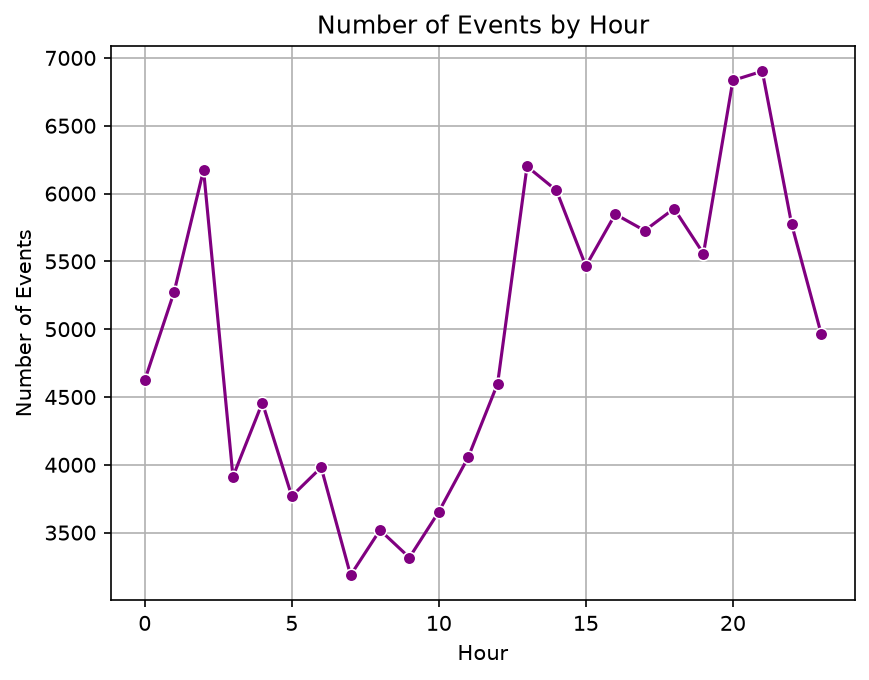

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# get hours
hour_df["datetime"] = pd.to_datetime(hour_df["datetime"])

#count hours
hourly_counts = hour_df.groupby(hour_df["datetime"].dt.hour).size().reset_index(name="count")

#plot
sns.lineplot(data=hourly_counts, x="datetime", y="count", marker="o", color="purple")
plt.title("Number of Events by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.grid(True)

plt.savefig("images/hourly-events.png")
plt.savefig("images/hourly-events.svg")
plt.show()



In the second plot, visualize the hourly event counts by type: by using the hue option available in Seaborn, you should be able to generate a plot where each event type is represented by a different color, with a legend allowing the audience to see what tye of event each color represents. Export this plot as images/events-by-type.svg and images/events-by-type.png.

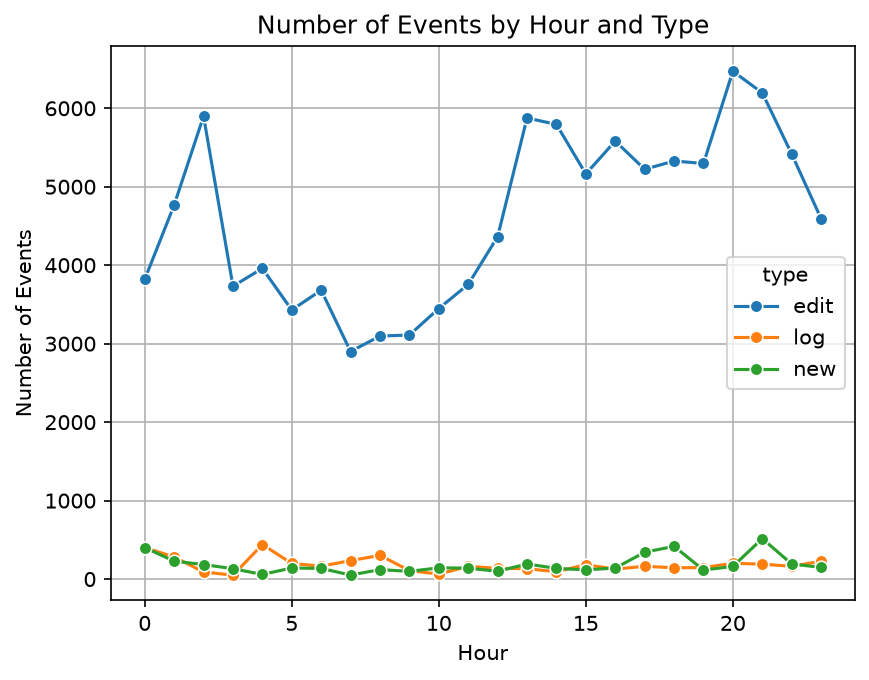

In [15]:
hourly_by_type = hour_df.groupby([hour_df["datetime"].dt.hour, "type"]).size().reset_index(name="count")

#hue time
sns.lineplot(data=hourly_by_type, x="datetime", y="count", hue="type", marker="o")

plt.title("Number of Events by Hour and Type")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.grid(True)

plt.savefig("images/events-by-type.png")
plt.savefig("images/events-by-type.svg")
plt.show()